In [2]:
from matplotlib import pyplot as plt
import pandas as pd
import polars as pl
import joblib

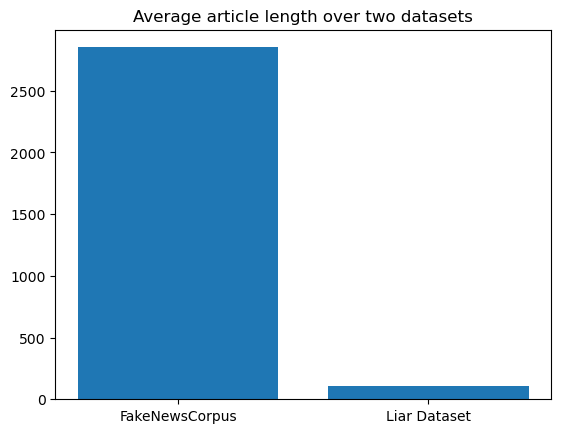

In [4]:
# Barplot over article counts
df_news = pl.read_csv('data/995,000_rows.csv', ignore_errors=True)
df_liar = pl.read_csv('liar_dataset/aggregated.csv')

def get_avg_len(series):
    return (series.str.len_chars().mean())

x_lab = ['FakeNewsCorpus', 'Liar Dataset']
# Average length of articles
news_avg = get_avg_len(df_news['content'])
liar_avg = get_avg_len(df_liar['title'])

plt.bar(x_lab, [news_avg, liar_avg])
plt.title('Average article length over two datasets')
plt.show()

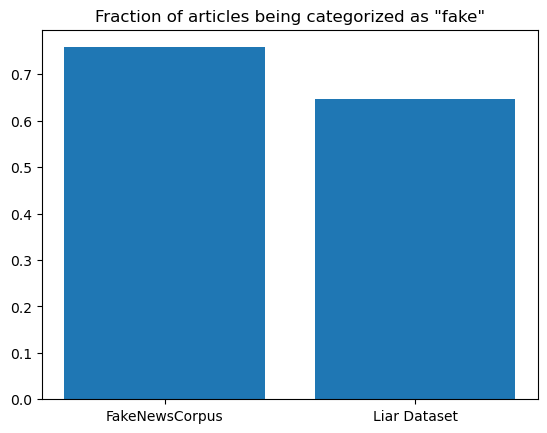

In [5]:
# Fraction of articles being classified as fake
y_news = pd.read_csv('data/y_train')['isfake']
y_liar = pd.read_csv('liar_dataset/aggregated.csv')['isfake']

real_labels = ['mostly-true', 'true']
fake_labels = ['false','pants-fire', 'half-true', 'barely-true']

y_liar = y_liar.apply(lambda x : 0 if x in real_labels else 1)

news_frac = sum(y_news) / len(y_news)
liar_frac = sum(y_liar) / len(y_liar)

plt.bar(x_lab, [news_frac, liar_frac])
plt.title('Fraction of articles being categorized as "fake"')
plt.show()

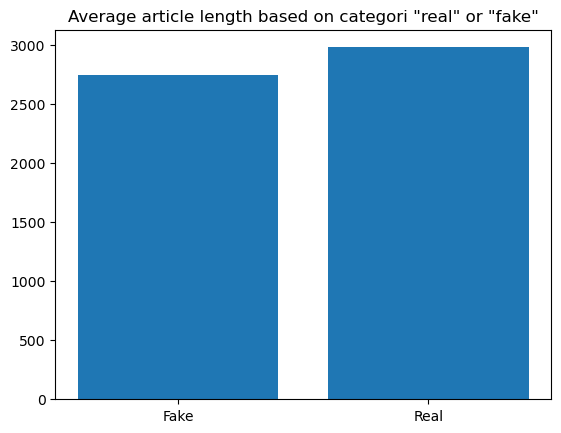

In [ ]:
# Testing difference in length based on real or fake categori.

real_labels = ['reliable']
fake_labels = ['bias','fake','unreliable','rumor','conspiracy','clickbait','junksci','satire','political','hate']

df = (
    df_news.select([
        pl.col('type').alias('isfake'),
        pl.col('content')
    ])
    .filter(pl.col('isfake').is_in(real_labels + fake_labels))
    .with_columns(
        pl.when(pl.col('isfake').is_in(fake_labels))
        .then(1)
        .otherwise(0)
        .alias('isfake')
    )
)

df_fake = df.filter(pl.col('isfake') == 1)
df_real = df.filter(pl.col('isfake') == 0)

fake_avg = get_avg_len(df_fake['content'])
real_avg = get_avg_len(df_real['content'])

x_lab = ['Fake', 'Real']

plt.bar(x_lab, [fake_avg, real_avg])
plt.title('Average article length based on categori "real" or "fake"')
plt.show()

In [23]:
# Last year updated
max_year = (
    df_news.select(
        pl.col("updated_at")
        .str.to_datetime()
        .dt.year()              
        .max()                  
    )
    .item()
)
max_year

2018